# 🚀 Hugging Face Masterclass: The Data Foundation

Welcome back, Aliens! Today we are stepping into the core of AI Engineering.

Before we can even think about training Large Language Models or building intelligent applications, we have to master **Data**. In the AI world, Hugging Face is our ultimate repository—it's the central hub where the community shares the best models and datasets.

In this session, we aren't just going to write code; we are going to understand the *why* behind it. We will:
1. Securely connect to the Hugging Face Hub.
2. Pull a massive dataset of Human Emotions.
3. Clean and transform it (because real-world data is always messy).
4. Learn the "Expressway" technique for handling data that is too big for our machines.
5. Create our very own dataset of student queries and push it live to the community!

Let's hit `Shift + Enter` and write some code!

### Module 1 : Step 1: Setting Up

First things first, we need the right tools. We are installing the Hugging Face `huggingface_hub` (to talk to the platform), `datasets` (to handle massive data efficiently), and a few visual libraries to make things look pretty later.

In [ ]:
# Upgrading and installing our core libraries
!pip install --quiet --upgrade huggingface_hub
# !pip install --quiet --upgrade huggingface_hub datasets pandas matplotlib wordcloud
print("✅ Libraries installed successfully! Ready to roll.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 46.4 MB/s eta 0:00:00
✅ Libraries installed successfully! Ready to roll.


## Step 2: The Secret Handshake (Authentication) 🔐

To download private data or upload our own creations, Hugging Face needs to know who we are.
**Crucial Step:** Go to the 🔑 icon on the left menu of Colab (Secrets).
Add two secrets:
* `HF_TOKEN` (Your read-access token)
* `HF_TOKEN_W` (Your write-access token)

We are doing this programmatically—no messy terminal commands. Pure Python!

In [ ]:
from google.colab import userdata
from huggingface_hub import login, HfApi

# Fetching your secure tokens from Colab Secrets
try:
    READ_TOKEN = userdata.get("HF_TOKEN")
    WRITE_TOKEN = userdata.get("HF_TOKEN_W")

    # Let's log in using our Write token so we have full permissions
    login(token=WRITE_TOKEN)
    print("✅ Authenticated successfully! Welcome to the Hub.")

except Exception as e:
    print("❌ Oops! Did you forget to add your tokens in the Colab Secrets tab?")
    print(e)

✅ Authenticated successfully! Welcome to the Hub.


## Module 2: Summoning the Data 🧠

Instead of boring standard examples, let's load something fascinating: the `dair-ai/emotion` dataset. This dataset contains thousands of text snippets labeled with human emotions like sadness, joy, love, anger, and surprise. Understanding context and emotion is a huge part of modern AI!

In [ ]:
from datasets import load_dataset

print("⏳ Fetching the Emotion dataset...")
# Loading just the training split
emotion_data = load_dataset("dair-ai/emotion", "split", split="train")

print(f"Total records fetched: {len(emotion_data)}\n")

# Let's inspect the very first record to understand its shape
first_record = emotion_data[0]
print("--- 📝 Sample Record ---")
print(f"Text: '{first_record['text']}'")
print(f"Emotion Label ID: {first_record['label']}")
# (Note: In this dataset, 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise)

## Module 3: Data Purification & Engineering 🧹

Raw data is rarely ready for action. Let's say we only want to train our model on positive, happy data. We need to filter out the rest.

Then, we'll engineer a new feature: counting the words. When you are optimizing AI systems, knowing the length of your text is critical for managing memory.

In [ ]:
# 1. Filter: Let's extract only the 'joy' records (label == 1)
def extract_joy(row):
    return row["label"] == 1

joy_dataset = emotion_data.filter(extract_joy)

# 2. Map: Let's create a brand new column that counts the number of words in each text
def count_words(row):
    # Splitting the text by spaces to count words
    return {"word_count": len(row["text"].split())}

# Applying the map function across the entire dataset
processed_joy_data = joy_dataset.map(count_words)

print(f"🎉 We now have {len(processed_joy_data)} joyful records ready to go!")
print(f"Sample word count of first record: {processed_joy_data[0]['word_count']} words.")

## Module 4: The Expressway Method (Streaming) 🛣️

What happens if a dataset is 500 Gigabytes? Google Colab will crash instantly.

Think of it like cruising down the Mumbai-Pune expressway in a fast car. You don't need to load the entire 150km physical map into your car at once; you just need to see the road immediately in front of you as you drive.

Hugging Face allows us to do exactly this using **Streaming**. We process the data chunk by chunk over the internet without saving it all to our local hard drive!

In [ ]:
# The magic keyword here is 'streaming=True'
streamed_emotions = load_dataset("dair-ai/emotion", "split", split="train", streaming=True)

# We turn our dataset into an iterator (a data pipeline)
data_pipeline = iter(streamed_emotions)

print("🌊 Live streaming data directly from the Hugging Face servers:\n")
for i in range(4):
    live_record = next(data_pipeline)
    print(f"Data packet {i+1}: {live_record['text']}")

## Module 5: The Lens (Visualizing the Data) 📷

When you are shooting a high-quality video, you rely on the lens of your camera to bring the subject into sharp focus. In data science, libraries like Matplotlib are our lenses. Let's visualize what our 'joy' data actually looks like.

🎨 Rendering visualization...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


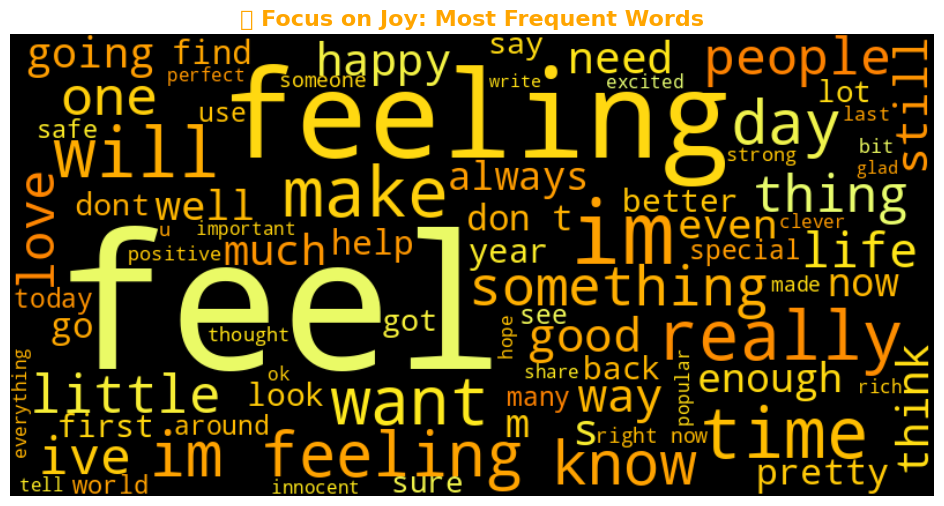

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Let's generate a Word Cloud to see the most frequent joyful words!
print("🎨 Rendering visualization...")

# We combine the first 1000 joyful texts into one massive string
all_joy_text = " ".join(processed_joy_data['text'][:1000])

# Configuring our WordCloud lens
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Wistia',
    max_words=80
).generate(all_joy_text)

# Displaying the image
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("✨ Focus on Joy: Most Frequent Words", fontsize=16, fontweight='bold', color='orange')
plt.show()

## Module 6: Building Your Own Dataset (Student Queries) 🚀

We've consumed data, now let's create it. As an educator, I see thousands of comments and messages. Let's build a custom dataset categorizing student queries, convert it into a Hugging Face format, and push it directly to your profile (`navinreddy20`).

In [ ]:
import pandas as pd
from datasets import Dataset

# 1. Let's draft some real-world examples from our community
query_data = {
    "student_message": [
        "Can I get doubt solving support on the WhatsApp number?",
        "Is the GIL entirely removed in Python 3.13?",
        "Will the new series cover Spring AI or Lang4J",
        "How do I access the new Learning Management System?",
        "Where can I find the multithreading tutorial for Python?"
    ],
    "category": [
        "Enrollment (WhatsApp is NOT for doubts)",
        "Technical (Sub-interpreter feature, not entirely removed)",
        "Course Content (Spring AI)",
        "Platform Access",
        "Video Request"
    ]
}

# 2. Wrap it in a Pandas DataFrame, then transform it into a HF Dataset
df = pd.DataFrame(query_data)
student_dataset = Dataset.from_pandas(df)

# 3. Pushing it to your Hub!
repo_name = "navinreddy20/student-support-queries"
print(f"🚀 Launching our custom dataset to {repo_name}...")

# We pass the WRITE_TOKEN to authenticate our push command
student_dataset.push_to_hub(repo_name, token=WRITE_TOKEN)

print("🎉 Boom! Your custom dataset is now live on the Hugging Face Hub.")
print(f"Check it out here: https://huggingface.co/datasets/{repo_name}")

### Awesome Job!

You've successfully set up your environment, wrangled a massive dataset, learned how to bypass memory limits, and published your own data to the world.

But right now, this data is just raw text. An AI model has no idea what English is—it only speaks mathematics. In our next session, we are going to dive into the exact process of transforming these words into numbers.

Get ready for the **Tokenization** masterclass next! Keep learning, keep coding!

## Module 7: The Translator (Tokenization for Fine-Tuning) 🔠

Welcome back, Aliens! We are now at the most critical bridge between raw data and actual AI model training.

Here is the golden rule of Machine Learning: **Models are basically massive calculators. They don't speak English. They only speak Math.** If you try to feed the word "Joy" or "Python" into a Transformer model during fine-tuning, it will crash. We need a translator to convert our human text into numbers. This is called a **Tokenizer**.

When we fine-tune a model, we *must* use the exact same tokenizer that the model was originally trained on. Since we are going to fine-tune a fast, lightweight model called **DistilBERT** later, let's load the DistilBERT tokenizer!

In [ ]:
# AutoTokenizer automatically grabs the correct dictionary for our specific model
from transformers import AutoTokenizer

print("⚙️ Booting up the Tokenizer...")

# We specify the exact model checkpoint we plan to fine-tune later
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

print(f"✅ Tokenizer for '{checkpoint}' is locked and loaded!")

⚙️ Booting up the Tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer for 'distilbert-base-uncased' is locked and loaded!


## Module 8: Under the Hood of Tokenization 🔍

Let's take a single joyful sentence and pass it through our tokenizer to see exactly what the AI will see during training. Watch how it chops the sentence into pieces (tokens) and assigns an ID to each piece.

In [ ]:
# A sample sentence from our emotion dataset
sample_text = "I absolutely love learning about AI engineering!"

# Pass it through the tokenizer
inputs = tokenizer(sample_text)

print(f"Original Text: {sample_text}\n")
print(f"Token IDs (The Math the AI sees): {inputs['input_ids']}")

# Let's decode those numbers back to text to see how it chopped the words
print(f"\nChopped Tokens: {tokenizer.convert_ids_to_tokens(inputs['input_ids'])}")

Original Text: I absolutely love learning about AI engineering!

Token IDs (The Math the AI sees): [101, 1045, 7078, 2293, 4083, 2055, 9932, 3330, 999, 102]

Chopped Tokens: ['[CLS]', 'i', 'absolutely', 'love', 'learning', 'about', 'ai', 'engineering', '!', '[SEP]']


Notice the `[CLS]` (Classification) at the beginning and `[SEP]` (Separator) at the end? The tokenizer adds these automatically so the model knows where a sequence starts and stops.

## Module 9: The GPU Rule (Padding & Truncation) 📏

When we fine-tune a model, we use GPUs. GPUs love processing data in uniform, rectangular blocks (batches).
But human sentences are all different lengths!

* **Padding:** If a sentence is too short, we add empty `[PAD]` tokens (ID: 0) to the end.
* **Truncation:** If a sentence is too long, we chop off the extra words.
* **Attention Mask:** We give the AI a map of 1s and 0s. "1" means "pay attention to this real word" and "0" means "ignore this fake padding word."

In [ ]:
# Two sentences of completely different lengths
batch_sentences = [
    "I am happy.",
    "I am feeling incredibly joyful today because my code compiled on the first try!"
]

# We turn on padding and truncation to make them equal length
batch_inputs = tokenizer(batch_sentences, padding=True, truncation=True)

print("Sentence 1 IDs:", batch_inputs["input_ids"][0])
print("Sentence 2 IDs:", batch_inputs["input_ids"][1])

print("\nNotice the 0s at the end of Sentence 1? That's our Padding!")
print("Attention Mask for Sentence 1:", batch_inputs["attention_mask"][0])

Sentence 1 IDs: [101, 1045, 2572, 3407, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sentence 2 IDs: [101, 1045, 2572, 3110, 11757, 6569, 3993, 2651, 2138, 2026, 3642, 9227, 2006, 1996, 2034, 3046, 999, 102]

Notice the 0s at the end of Sentence 1? That's our Padding!
Attention Mask for Sentence 1: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Module 10: Tokenizing the Entire Dataset 🏭

We know how it works on one or two sentences. Now, let's process our entire dataset! We will use our trusty `.map()` function to run the tokenizer over every single row at blazing speed.

This will output the final, perfect tensors (matrices) we need to start Fine-Tuning.

In [ ]:
# 1. Define a function that tokenizes a batch of text
def tokenize_function(examples):
    # Padding and truncation ensure all data is perfectly uniform for the model
    return tokenizer(examples["text"], padding="max_length", truncation=True)

print("⏳ Translating our entire dataset into Math... Hang tight!")

# 2. Apply it using map! (batched=True processes multiple rows at once for massive speed)
tokenized_datasets = emotion_data.map(tokenize_function, batched=True)

print("\n🎉 Tokenization Complete!")
print("Let's look at the columns we have now:")
print(tokenized_datasets.column_names)

# Notice we now have 'input_ids' and 'attention_mask'.
# This data is 100% ready to be plugged into the Hugging Face Trainer!

⏳ Translating our entire dataset into Math... Hang tight!


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]


🎉 Tokenization Complete!
Let's look at the columns we have now:
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## Module 11: Loading the Brain (The Model) 🧠

It is time to bring in DistilBERT.

When we load the model, we use a specific class called `AutoModelForSequenceClassification`. Why? Because we want the model to look at a *sequence* of text and *classify* it.

We also need to tell the model how many output categories there are. Since our emotion dataset has 6 emotions (sadness, joy, love, anger, fear, surprise), we set `num_labels=6`. Hugging Face will automatically attach a fresh, untrained "classification head" on top of the pre-trained DistilBERT brain!

In [ ]:
from transformers import AutoModelForSequenceClassification
import torch

print("🚀 Downloading the DistilBERT Model...")

# We use the exact same checkpoint name we used for the tokenizer!
checkpoint = "distilbert-base-uncased"

# Loading the model and telling it we have 6 specific emotion categories
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=6)

# Let's check if our Colab GPU is ready!
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Model loaded! We are going to train using: {device.upper()}")
if device == "cpu":
    print("⚠️ WARNING: You are on a CPU! Go to Runtime -> Change runtime type -> Select T4 GPU!")


🚀 Downloading the DistilBERT Model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded! We are going to train using: CUDA


## Module 12: The Scoreboard (Defining Metrics) 📊

Here is a funny thing about AI: Models don't actually care about "Accuracy" during training. They only care about minimizing a mathematical number called "Loss" (their mistake counter).

But as humans, "Loss went from 1.4 to 0.8" doesn't mean much to us. We want to see a percentage! So, we have to write a quick function to calculate human-readable accuracy so we can see exactly how smart our model is getting at the end of every round.

In [ ]:
import numpy as np

# This function takes the model's complex predictions and turns them into a simple Accuracy score
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # The model outputs probabilities for all 6 classes. We pick the highest one!
    predictions = np.argmax(logits, axis=-1)

    # We compare the model's guesses to the actual true labels
    accuracy = np.mean(predictions == labels)

    return {"accuracy": accuracy}

print("✅ Scoreboard ready! We will track our accuracy during training.")

✅ Scoreboard ready! We will track our accuracy during training.


## Module 13: The Training Blueprint (Hyperparameters) 🗺️

Before we send the model to the gym, we have to give it a workout routine. In Hugging Face, we use `TrainingArguments` to define the rules of the training process.

* **Epochs:** How many times the model will read the entire dataset. Think of this like reading a textbook. Reading it once is okay, reading it twice is better. (We will do 2 to save time).
* **Batch Size:** How many sentences the GPU processes at the exact same time.
* **Learning Rate:** How fast the model adjusts its brain. If it learns too fast, it forgets the old stuff. If it learns too slow, it takes forever. (2e-5 is a great sweet spot).

In [ ]:
from transformers import TrainingArguments

print("⚙️ Setting up the Training Blueprint...")

training_args = TrainingArguments(
    output_dir="emotion-distilbert-model", # Where to save our new custom model
    learning_rate=2e-5,                    # The speed of learning
    per_device_train_batch_size=16,        # Processing 16 rows at a time
    per_device_eval_batch_size=16,
    num_train_epochs=2,                    # Reading the dataset 2 times
    weight_decay=0.01,                     # A trick to prevent overfitting
    eval_strategy="epoch",                 # FIX: We changed this to the new parameter name!
    save_strategy="epoch",                 # Save a backup at the end of each epoch
    logging_steps=100                      # Print an update every 100 steps
)

print("✅ Blueprint locked in!")

⚙️ Setting up the Training Blueprint...
✅ Blueprint locked in!


## Module 14: The Main Event! (Fine-Tuning) 🔥

This is it. The `Trainer` API is Hugging Face's masterpiece. It takes our Model, our Blueprint, our Tokenized Data, and our Scoreboard, and handles all the complex PyTorch math for us automatically.

Run this cell, sit back, and watch your AI learn in real-time!

In [ ]:
from transformers import Trainer

# Split the data
split_data = tokenized_datasets.train_test_split(test_size=0.1)
train_set = split_data["train"]
test_set = split_data["test"]

# Set up Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_set,
    eval_dataset=test_set,
    compute_metrics=compute_metrics,
)

print("🚀 IGNITION! Starting the Fine-Tuning Process...\n")
trainer.train()
print("\n🎉 Training Complete!")

# --- THE FIX: EXPLICITLY SAVE THE FINAL MODEL ---
print("💾 Saving the final brain to our hard drive...")
trainer.save_model("emotion-distilbert-model")
# We also save the tokenizer in the same folder so they stay as a matched pair!
tokenizer.save_pretrained("emotion-distilbert-model")
print("✅ Model saved successfully!")

🚀 IGNITION! Starting the Fine-Tuning Process...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.163939,0.145291,0.931250
2,0.087436,0.127908,0.943750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training Complete!
💾 Saving the final brain to our hard drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!


## Module 15: The Ultimate Test (Before vs. After) 🥊

We spent 20+ minutes training this model, but did it actually learn anything?

Let's do a side-by-side comparison. We are going to load **two** AI engines:
1. **The Base Intern:** The raw `distilbert-base-uncased` model straight from the internet.
2. **The Specialized Expert:** Our custom `emotion-distilbert-model` from our hard drive.

We will feed the exact same sentence into both and watch how they react!
*(Note: You will see a red warning when loading the base model. That is normal! It is Hugging Face warning us that the base model has no idea how to classify things yet).*

In [ ]:
from transformers import pipeline
import warnings

# Suppress some of the messy warning logs for a cleaner presentation
warnings.filterwarnings('ignore')

print("🔌 Booting up the Base Intern (Untrained)...")
# Loading the raw model. It defaults to 2 random labels because it isn't trained!
base_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased",
    tokenizer="distilbert-base-uncased"
)

print("🔌 Booting up our Custom Expert (Fine-Tuned)...")
# Loading our newly trained brain
expert_classifier = pipeline(
    "text-classification",
    model="emotion-distilbert-model",
    tokenizer="emotion-distilbert-model"
)

# Our translation dictionary for the expert model
emotion_map = {
    "LABEL_0": "Sadness 😢", "LABEL_1": "Joy 😄", "LABEL_2": "Love ❤️",
    "LABEL_3": "Anger 😡", "LABEL_4": "Fear 😨", "LABEL_5": "Surprise 😲"
}

# The test sentence
test_sentence = "I was so frustrated when my code crashed, but finding the bug made me so incredibly happy!"

print("\n" + "="*60)
print(f"📝 TEST SENTENCE: '{test_sentence}'")
print("="*60)

# --- 1. BASE MODEL PREDICTION ---
base_result = base_classifier(test_sentence)[0]
print("\n❌ BEFORE FINE-TUNING (Base Model):")
print(f"Prediction: {base_result['label']} (It has no idea what this means)")
print(f"Confidence: {base_result['score']*100:.1f}% (Guessing blindly)")

# --- 2. EXPERT MODEL PREDICTION ---
expert_result = expert_classifier(test_sentence)[0]
print("\n✅ AFTER FINE-TUNING (Our Custom Model):")
print(f"Prediction: {emotion_map.get(expert_result['label'], expert_result['label'])}")
print(f"Confidence: {expert_result['score']*100:.1f}% (Highly confident!)")
print("="*60)

🔌 Booting up the Base Intern (Untrained)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔌 Booting up our Custom Expert (Fine-Tuned)...


OSError: emotion-distilbert-model is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

### 🎯 Masterclass Complete!

Look at that difference! The base model had no idea what was going on. But YOUR model? It read a complex sentence about coding frustration and joy, and accurately identified the overriding emotion.

You didn't just *use* AI today. You *engineered* it. You took raw data, translated it into mathematical tensors, bolted a new classification head onto a massive Transformer, and fundamentally altered its neural pathways on a GPU.

The next time you build an application, remember that you have the power to create proprietary AI engines that do exactly what you need them to do. Keep learning, keep building, and stay curious, Aliens! 🚀